# **Statistical Testing**

## **Setup**

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "./.matplotlib_cache")

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from scipy import stats
from scipy.stats import jarque_bera, skew, kurtosis

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.sm_exceptions import InterpolationWarning

plt.style.use("default")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df_model = pd.read_csv("../data/processed/model_data.csv", parse_dates=["Date"], index_col="Date")

required_cols = ["fx_return", "dxy_return", "vix_change", "us10y_change", "vnindex_return", "oil_return"]

display(df_model.head())

,usd_vnd,log_usd_vnd,fx_return,abs_return,squared_return,rolling_vol_22d,vix,vix_change,us_10y,us10y_change,dxy,dxy_return,vnindex,vnindex_return,wti_oil,log_oil,oil_return,abs_oil_return,squared_oil_return,vietnam_fx_devaluation_2010,vietnam_fx_devaluation_2011,covid_2020,fed_hiking_2022_2023,crisis_dummy
Date,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-26,"18,469.000000",9.823849,0.000000,0.000000,0.000000,0.020919,24.550000,-0.860000,3.650000,-0.010000,78.430000,0.306472,497.900000,3.471911,74.670000,4.313078,-0.307549,0.307549,0.094586,0,0,0,0,0
2010-01-27,"18,474.043968",9.824122,0.027307,0.027307,0.000746,0.021482,23.140000,-1.410000,3.660000,0.010000,78.680000,0.318249,486.410000,-2.334736,73.640000,4.299188,-1.389005,1.389005,1.929335,0,0,0,0,0
2010-01-28,"18,469.608260",9.823882,-0.024013,0.024013,0.000577,0.021600,23.730000,0.590000,3.680000,0.020000,78.900002,0.279225,481.760000,-0.960582,73.620000,4.298917,-0.027163,0.027163,0.000738,0,0,0,0,0
2010-01-29,"18,474.043968",9.824122,0.024013,0.024013,0.000577,0.021795,24.620000,0.890000,3.630000,-0.050000,79.459999,0.707249,481.960000,0.041506,72.850000,4.288403,-1.051420,1.051420,1.105483,0,0,0,0,0
2010-02-01,"18,469.000000",9.823849,-0.027307,0.027307,0.000746,0.022088,22.590000,-2.030000,3.680000,0.050000,79.239998,-0.277254,486.950000,1.030033,74.410000,4.309590,2.118781,2.118781,4.489232,0,0,0,0,0


In [3]:
display(Markdown("### Descriptive statistics for model variables"))
desc = df_model[required_cols].describe().T
desc["skewness"] = df_model[required_cols].skew()
desc["kurtosis"] = df_model[required_cols].kurtosis() + 3  # Pearson kurtosis
# pandas kurtosis is Fisher by default; +3 converts to Pearson kurtosis.
display(desc)

display(Markdown("### Crisis dummy counts"))
crisis_cols = ["vietnam_fx_devaluation_2010", "vietnam_fx_devaluation_2011", "covid_2020", "fed_hiking_2022_2023", "crisis_dummy"]
crisis_cols = [c for c in crisis_cols if c in df_model.columns]
display(df_model[crisis_cols].sum().to_frame("number_of_days"))


### Descriptive statistics for model variables

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
fx_return,"4,006.000000",0.008825,0.212901,-2.394219,-0.044976,0.000000,0.052252,6.213884,6.464004,213.182783
dxy_return,"4,006.000000",0.005708,0.447373,-2.398774,-0.253266,0.009753,0.260709,2.032029,-0.034819,4.534737
vix_change,"4,006.000000",-0.002611,1.873916,-18.710000,-0.740000,-0.100000,0.570000,24.860000,1.911134,32.261917
us10y_change,"4,006.000000",0.000130,0.053548,-0.300000,-0.030000,0.000000,0.030000,0.290000,0.004308,4.624597
vnindex_return,"4,006.000000",0.032731,1.176298,-6.964228,-0.456196,0.062998,0.651785,6.546905,-0.810479,7.270024
oil_return,"4,004.000000",0.011282,2.713639,-28.138208,-1.168721,0.068743,1.221527,42.583241,1.032620,43.538261


### Crisis dummy counts

,number_of_days
vietnam_fx_devaluation_2010,24
vietnam_fx_devaluation_2011,6
covid_2020,213
fed_hiking_2022_2023,356
crisis_dummy,599


## **Stationarity tests: ADF and KPSS**

### ADF test

- H₀: series has a unit root, non-stationary
- H₁: series is stationary
- Nếu `p-value < 0.05`: reject H₀ → stationary

### KPSS test

- H₀: series is stationary
- H₁: series is non-stationary
- Nếu `p-value > 0.05`: not reject H₀ → stationary

A variable is considered more stationary when:
- ADF p-value < 0.05
- KPSS p-value > 0.05

In [4]:
def run_adf(series, name, regression="c", autolag="AIC"):
    s = pd.Series(series).dropna()
    result = adfuller(s, regression=regression, autolag=autolag)
    stat, pval, usedlag, nobs, crit, icbest = result
    return {
        "Variable": name,
        "ADF Stat": stat,
        "P-value": pval,
        "Lags": usedlag,
        "Obs": nobs,
        "Critical 1%": crit["1%"],
        "Critical 5%": crit["5%"],
        "Critical 10%": crit["10%"],
        "Stationary (α=0.05)": "Yes" if pval < 0.05 else "No"
    }

def run_kpss(series, name, regression="c", nlags="auto"):
    s = pd.Series(series).dropna()
    stat, pval, lags, crit = kpss(s, regression=regression, nlags=nlags)
    return {
        "Variable": name,
        "KPSS Stat": stat,
        "P-value": pval,
        "Lags": lags,
        "Critical 1%": crit["1%"],
        "Critical 5%": crit["5%"],
        "Critical 10%": crit["10%"],
        "Stationary (α=0.05)": "Yes" if pval > 0.05 else "No"
    }

adf_results = pd.DataFrame([run_adf(df_model[v], v) for v in required_cols])
kpss_results = pd.DataFrame([run_kpss(df_model[v], v) for v in required_cols])

display(Markdown("### ADF test results"))
display(adf_results)

display(Markdown("### KPSS test results"))
display(kpss_results)

stationarity_summary = adf_results[["Variable", "Stationary (α=0.05)"]].merge(
    kpss_results[["Variable", "Stationary (α=0.05)"]],
    on="Variable",
    suffixes=(" ADF", " KPSS")
)
stationarity_summary["Final conclusion"] = np.where(
    (stationarity_summary["Stationary (α=0.05) ADF"] == "Yes") &
    (stationarity_summary["Stationary (α=0.05) KPSS"] == "Yes"),
    "Stationary I(0)",
    "Check transformation"
)

display(Markdown("### Stationarity conclusion"))
display(stationarity_summary)

/var/folders/rr/4y7qftxx1x3f53wj4d9l4m1h0000gn/T/ipykernel_10985/26498077.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(s, regression=regression, nlags=nlags)
/var/folders/rr/4y7qftxx1x3f53wj4d9l4m1h0000gn/T/ipykernel_10985/26498077.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(s, regression=regression, nlags=nlags)
/var/folders/rr/4y7qftxx1x3f53wj4d9l4m1h0000gn/T/ipykernel_10985/26498077.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(s, regression=regression, nlags=nlags)
/var/folders/rr/4y7qftxx1x3f53wj4d9l4m1h000

### ADF test results

,Variable,ADF Stat,P-value,Lags,Obs,Critical 1%,Critical 5%,Critical 10%,Stationary (α=0.05)
0,fx_return,-32.496051,0.000000,3,4002,-3.431985,-2.862262,-2.567155,Yes
1,dxy_return,-62.460439,0.000000,0,4005,-3.431984,-2.862262,-2.567154,Yes
2,vix_change,-15.168494,0.000000,25,3980,-3.431994,-2.862266,-2.567157,Yes
3,us10y_change,-47.190492,0.000000,1,4004,-3.431984,-2.862262,-2.567154,Yes
4,vnindex_return,-41.583527,0.000000,1,4004,-3.431984,-2.862262,-2.567154,Yes
5,oil_return,-11.971033,0.000000,23,3980,-3.431994,-2.862266,-2.567157,Yes


### KPSS test results

,Variable,KPSS Stat,P-value,Lags,Critical 1%,Critical 5%,Critical 10%,Stationary (α=0.05)
0,fx_return,0.130301,0.100000,5,0.739000,0.463000,0.347000,Yes
1,dxy_return,0.079742,0.100000,11,0.739000,0.463000,0.347000,Yes
2,vix_change,0.010871,0.100000,34,0.739000,0.463000,0.347000,Yes
3,us10y_change,0.256911,0.100000,8,0.739000,0.463000,0.347000,Yes
4,vnindex_return,0.072403,0.100000,8,0.739000,0.463000,0.347000,Yes
5,oil_return,0.069180,0.100000,1,0.739000,0.463000,0.347000,Yes


### Stationarity conclusion

,Variable,Stationary (α=0.05) ADF,Stationary (α=0.05) KPSS,Final conclusion
0,fx_return,Yes,Yes,Stationary I(0)
1,dxy_return,Yes,Yes,Stationary I(0)
2,vix_change,Yes,Yes,Stationary I(0)
3,us10y_change,Yes,Yes,Stationary I(0)
4,vnindex_return,Yes,Yes,Stationary I(0)
5,oil_return,Yes,Yes,Stationary I(0)


## **ACF/PACF and Ljung–Box autocorrelation tests**

### ACF/PACF

- ACF measures the correlation between `fx_return_t` and `fx_return_{t-k}`.
- PACF measures the partial correlation after removing the effects of intermediate lags.
- Significant spikes in short lags suggest the need to add AR/MA terms to the mean equation.

### Ljung–Box test

- H₀: no autocorrelation up to selected lag
- H₁: autocorrelation exists
- Nếu `p-value < 0.05`: chuỗi còn autocorrelation

95% confidence bound: ±0.0310
Significant ACF lags: [1, 3, 4, 5, 8, 9, 10, 12, 13, 18]
Significant PACF lags: [1, 2, 3, 4, 5, 8, 10, 12]


,Lag,ACF,PACF,ACF significant,PACF significant
0,0,1.000000,1.000000,False,False
1,1,-0.121564,-0.121564,True,True
2,2,-0.029312,-0.044752,False,True
3,3,0.082796,0.074888,True,True
4,4,-0.052165,-0.034627,True,True
5,5,0.043799,0.039284,True,True
6,6,-0.001472,-0.000349,False,False
7,7,-0.026076,-0.017632,False,False
8,8,0.064024,0.052129,True,True
9,9,-0.037490,-0.022364,True,False


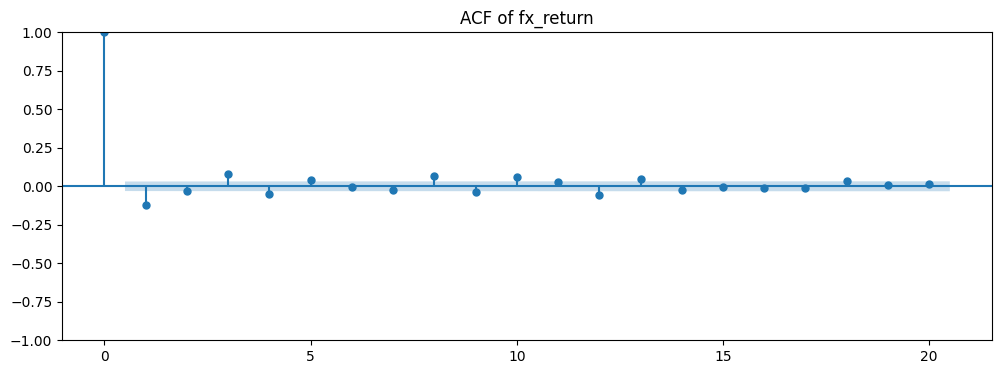

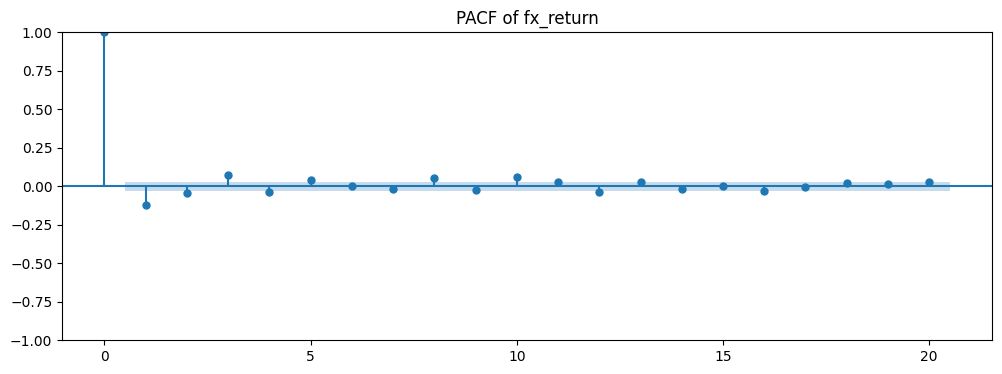

### Ljung–Box test on fx_return

,Lag,lb_stat,lb_pvalue,Conclusion
0,5,108.801517,0.000000,Autocorrelation detected
1,10,146.884055,0.000000,Autocorrelation detected
2,20,181.150565,0.000000,Autocorrelation detected


In [5]:
y = df_model["fx_return"].dropna()
n = len(y)
max_lag = 20
conf_bound = 1.96 / np.sqrt(n)

acf_vals = acf(y, nlags=max_lag, fft=True)
pacf_vals = pacf(y, nlags=max_lag, method="ywm")
acf_pacf_results = pd.DataFrame({
    "Lag": range(max_lag + 1),
    "ACF": acf_vals,
    "PACF": pacf_vals
})
acf_pacf_results["ACF significant"] = acf_pacf_results["ACF"].abs() > conf_bound
acf_pacf_results["PACF significant"] = acf_pacf_results["PACF"].abs() > conf_bound
acf_pacf_results.loc[acf_pacf_results["Lag"] == 0, ["ACF significant", "PACF significant"]] = False

print(f"95% confidence bound: ±{conf_bound:.4f}")
print("Significant ACF lags:", acf_pacf_results.loc[acf_pacf_results["ACF significant"], "Lag"].tolist())
print("Significant PACF lags:", acf_pacf_results.loc[acf_pacf_results["PACF significant"], "Lag"].tolist())
display(acf_pacf_results)

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(y, lags=max_lag, ax=ax)
ax.set_title("ACF of fx_return")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(y, lags=max_lag, ax=ax, method="ywm")
ax.set_title("PACF of fx_return")
plt.show()

lb_lags = [5, 10, 20]
ljung_return = acorr_ljungbox(y, lags=lb_lags, return_df=True)
ljung_return.index.name = "Lag"
ljung_return = ljung_return.reset_index()
ljung_return["Conclusion"] = np.where(ljung_return["lb_pvalue"] < 0.05, "Autocorrelation detected", "No autocorrelation")

display(Markdown("### Ljung–Box test on fx_return"))
display(ljung_return)

## **Volatility clustering tests**

Tests in this section:

1. Ljung-Box on `abs_return`
2. Ljung-Box on `squared_return`
3. ACF of volatility proxy

If the p-values ​​are close to 0, volatility clustering is very clear and the GARCH-family is a suitable choice.

,Variable,Lag,lb_stat,lb_pvalue,Conclusion
0,abs_return,5,"1,007.363411",0.000000,Volatility clustering detected
1,abs_return,10,"1,482.522372",0.000000,Volatility clustering detected
2,abs_return,20,"1,685.431819",0.000000,Volatility clustering detected
3,squared_return,5,48.891057,0.000000,Volatility clustering detected
4,squared_return,10,83.507288,0.000000,Volatility clustering detected
5,squared_return,20,90.328466,0.000000,Volatility clustering detected


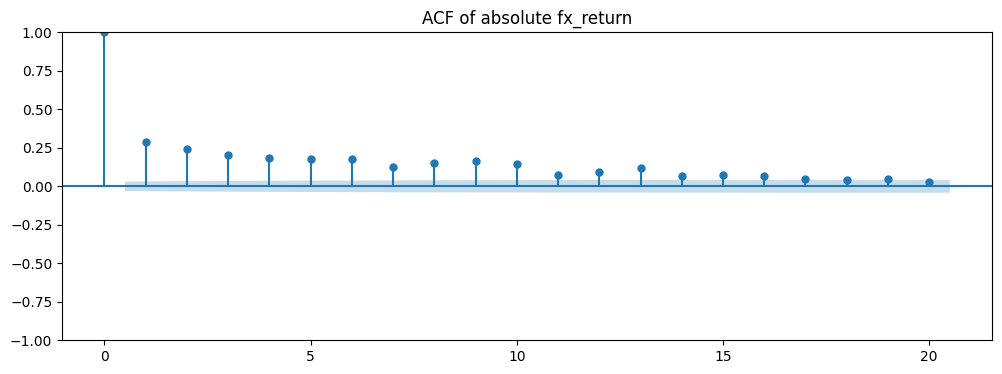

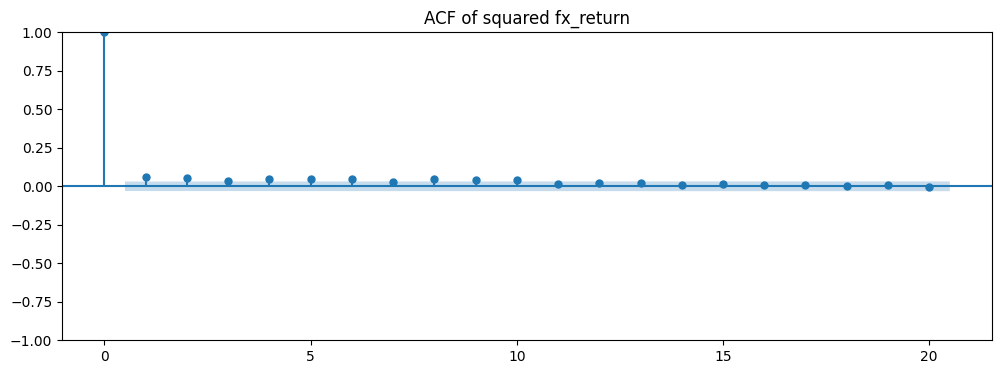

In [6]:
vol_test_data = pd.DataFrame({
    "abs_return": df_model["fx_return"].abs(),
    "squared_return": df_model["fx_return"] ** 2
}).dropna()

vol_lb_tables = []
for col in vol_test_data.columns:
    tmp = acorr_ljungbox(vol_test_data[col], lags=lb_lags, return_df=True)
    tmp.index.name = "Lag"
    tmp = tmp.reset_index()
    tmp.insert(0, "Variable", col)
    tmp["Conclusion"] = np.where(tmp["lb_pvalue"] < 0.05, "Volatility clustering detected", "No volatility clustering")
    vol_lb_tables.append(tmp)

vol_ljung = pd.concat(vol_lb_tables, ignore_index=True)
display(vol_ljung)

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(vol_test_data["abs_return"], lags=max_lag, ax=ax)
ax.set_title("ACF of absolute fx_return")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(vol_test_data["squared_return"], lags=max_lag, ax=ax)
ax.set_title("ACF of squared fx_return")
plt.show()

## **ARCH-LM test**

ARCH-LM checks for conditional heteroskedasticity.

- H₀: no ARCH effect
- H₁: ARCH effect exists
- If `p-value < 0.05`: ARCH effect exists → use GARCH-family

Notebook runs ARCH-LM in two ways:

1. On residuals from the constant-mean model

2. On residuals from the mean equation with global shock variables and crisis dummies

The second method is stricter because it checks for ARCH after controlling for explanatory variables in the mean equation.

In [7]:
# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

# Choose only ONE dummy strategy:
# "aggregate"   = use crisis_dummy only
# "individual"  = use individual crisis/event dummies only
# "none"        = use no crisis/event dummy
DUMMY_MODE = "aggregate"

BASE_MEAN_X_COLS = [
    "dxy_return",
    "vix_change",
    "us10y_change",
    "vnindex_return",
]

TARGET_COL = "fx_return"

if "lb_lags" not in globals():
    lb_lags = [10, 20]


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def arch_lm_from_resid(resid, nlags=10, label="residuals"):
    resid = pd.Series(resid).replace([np.inf, -np.inf], np.nan).dropna()

    lm_stat, lm_pval, f_stat, f_pval = het_arch(resid, nlags=nlags)

    return {
        "Residual source": label,
        "Lags": nlags,
        "ARCH-LM Stat": float(lm_stat),
        "ARCH-LM P-value": float(lm_pval),
        "F Stat": float(f_stat),
        "F P-value": float(f_pval),
        "Conclusion": "ARCH effect detected" if lm_pval < 0.05 else "No ARCH effect",
    }


def clean_regressor_matrix(X, tol=1e-10):
    """
    Drop constant/zero-variance columns and then remove linearly dependent columns.
    Keeps columns from left to right.
    """
    X = X.copy()

    # Drop all-NA columns
    X = X.dropna(axis=1, how="all")

    # Drop zero-variance columns before adding constant
    nunique = X.nunique(dropna=True)
    zero_var_cols = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=zero_var_cols, errors="ignore")

    kept_cols = []
    current = pd.DataFrame(index=X.index)

    for col in X.columns:
        trial = pd.concat([current, X[[col]]], axis=1)

        rank_before = np.linalg.matrix_rank(current.to_numpy()) if current.shape[1] > 0 else 0
        rank_after = np.linalg.matrix_rank(trial.to_numpy())

        if rank_after > rank_before:
            kept_cols.append(col)
            current = trial

    dropped_cols = [c for c in X.columns if c not in kept_cols]

    return X[kept_cols], zero_var_cols + dropped_cols


def build_mean_equation_columns(df_model, dummy_mode="aggregate"):
    base_cols = [c for c in BASE_MEAN_X_COLS if c in df_model.columns]

    # crisis_cols may exist from previous cells
    available_crisis_cols = crisis_cols if "crisis_cols" in globals() else []
    available_crisis_cols = [c for c in available_crisis_cols if c in df_model.columns]

    # Do not let crisis_dummy appear inside individual dummy list
    individual_dummy_cols = [
        c for c in available_crisis_cols
        if c != "crisis_dummy"
    ]

    if dummy_mode == "aggregate":
        dummy_cols = ["crisis_dummy"] if "crisis_dummy" in df_model.columns else []

    elif dummy_mode == "individual":
        dummy_cols = individual_dummy_cols

    elif dummy_mode == "none":
        dummy_cols = []

    else:
        raise ValueError("DUMMY_MODE must be one of: 'aggregate', 'individual', 'none'.")

    mean_x_cols = base_cols + dummy_cols

    # Remove duplicated columns while preserving order
    mean_x_cols = list(dict.fromkeys(mean_x_cols))

    return mean_x_cols


# ------------------------------------------------------------
# Constant mean residuals
# ------------------------------------------------------------

y_arch = (
    df_model[TARGET_COL]
    .astype(float)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

resid_constant = y_arch - y_arch.mean()


# ------------------------------------------------------------
# OLS mean equation residuals
# ------------------------------------------------------------

mean_x_cols_raw = build_mean_equation_columns(df_model, dummy_mode=DUMMY_MODE)

mean_df = (
    df_model[[TARGET_COL] + mean_x_cols_raw]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

y_mean = mean_df[TARGET_COL].astype(float)
X_raw = mean_df[mean_x_cols_raw].astype(float)

X_clean, dropped_cols = clean_regressor_matrix(X_raw)

X = sm.add_constant(X_clean, has_constant="add")

# Final rank check
rank_X = np.linalg.matrix_rank(X.to_numpy())
n_cols_X = X.shape[1]

if rank_X < n_cols_X:
    raise ValueError(
        f"Design matrix is still rank deficient: rank={rank_X}, columns={n_cols_X}. "
        "Inspect dummy variables."
    )

mean_model = OLS(y_mean, X).fit()
resid_mean_eq = mean_model.resid


# ------------------------------------------------------------
# ARCH-LM results
# ------------------------------------------------------------

arch_results = pd.DataFrame([
    arch_lm_from_resid(
        resid_constant,
        nlags=10,
        label="Constant mean residuals"
    ),
    arch_lm_from_resid(
        resid_mean_eq,
        nlags=10,
        label=f"OLS mean equation residuals ({DUMMY_MODE} dummy mode)"
    ),
])


# ------------------------------------------------------------
# Ljung-Box on squared OLS residuals
# ------------------------------------------------------------

sq_resid_lb = acorr_ljungbox(
    resid_mean_eq ** 2,
    lags=lb_lags,
    return_df=True
)

sq_resid_lb.index.name = "Lag"
sq_resid_lb = sq_resid_lb.reset_index()

sq_resid_lb["Conclusion"] = np.where(
    sq_resid_lb["lb_pvalue"] < 0.05,
    "ARCH/volatility clustering remains",
    "No remaining ARCH"
)


# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------

display(Markdown("### Mean equation used only to obtain residuals before ARCH test"))

print("Dummy mode:", DUMMY_MODE)
print("Original regressors:", mean_x_cols_raw)
print("Used regressors after collinearity cleaning:", list(X_clean.columns))
print("Dropped regressors:", dropped_cols)
print("Design matrix rank:", rank_X)
print("Number of columns including constant:", n_cols_X)

display(Markdown("### Compact OLS mean equation diagnostics"))
ols_info = pd.DataFrame([{
    "n_obs": int(mean_model.nobs),
    "r_squared": float(mean_model.rsquared),
    "adj_r_squared": float(mean_model.rsquared_adj),
    "aic": float(mean_model.aic),
    "bic": float(mean_model.bic),
    "condition_number": float(mean_model.condition_number),
}])
display(ols_info)

display(Markdown("### ARCH-LM results"))
display(arch_results)

display(Markdown("### Ljung–Box on squared OLS residuals"))
display(sq_resid_lb)

### Mean equation used only to obtain residuals before ARCH test

Dummy mode: aggregate
Original regressors: ['dxy_return', 'vix_change', 'us10y_change', 'vnindex_return', 'crisis_dummy']
Used regressors after collinearity cleaning: ['dxy_return', 'vix_change', 'us10y_change', 'vnindex_return', 'crisis_dummy']
Dropped regressors: []
Design matrix rank: 6
Number of columns including constant: 6


### Compact OLS mean equation diagnostics

,n_obs,r_squared,adj_r_squared,aic,bic,condition_number
0,4006,0.005198,0.003954,"-1,035.310897",-997.537606,36.707328


### ARCH-LM results

,Residual source,Lags,ARCH-LM Stat,ARCH-LM P-value,F Stat,F P-value,Conclusion
0,Constant mean residuals,10,59.522287,0.000000,6.025598,0.000000,ARCH effect detected
1,OLS mean equation residuals (aggregate dummy m...,10,61.300416,0.000000,6.208407,0.000000,ARCH effect detected


### Ljung–Box on squared OLS residuals

,Lag,lb_stat,lb_pvalue,Conclusion
0,5,51.021827,0.000000,ARCH/volatility clustering remains
1,10,86.952695,0.000000,ARCH/volatility clustering remains
2,20,94.266539,0.000000,ARCH/volatility clustering remains


## **Normality test: Jarque–Bera**
Jarque–Bera tests for normality based on skewness and kurtosis.

- H₀: normal distribution
- H₁: non-normal distribution
- If `p-value < 0.05`: reject normality

With financial data, Jarque–Bera often rejects normality. If kurtosis is very high, Student-t or GED in GARCH should be used instead of Gaussian.

,Variable,JB Statistic,P-value,Skewness,Kurtosis (Pearson),Conclusion
0,fx_return,"7,383,227.037075",0.000000,6.461584,212.919043,Non-normal


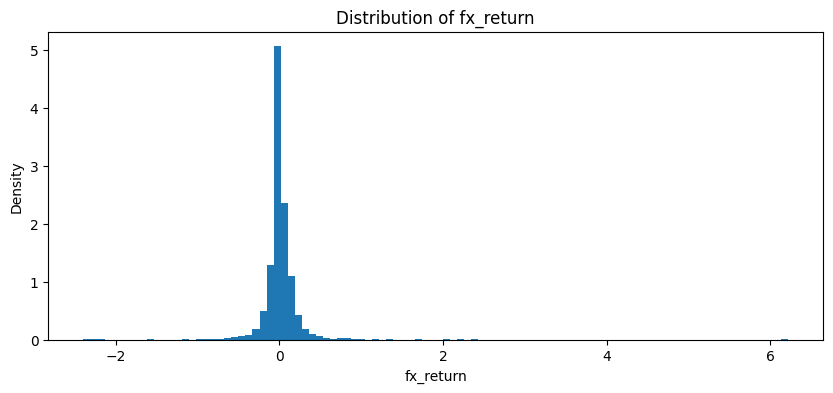

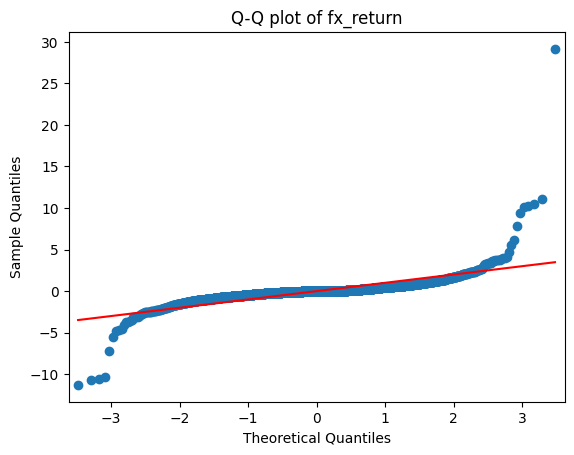

In [8]:
def normality_test(series, name):
    s = pd.Series(series).dropna()
    jb = jarque_bera(s)
    return {
        "Variable": name,
        "JB Statistic": jb.statistic,
        "P-value": jb.pvalue,
        "Skewness": skew(s),
        "Kurtosis (Pearson)": kurtosis(s, fisher=False),
        "Conclusion": "Non-normal" if jb.pvalue < 0.05 else "Cannot reject normality"
    }

normality_results = pd.DataFrame([normality_test(df_model["fx_return"], "fx_return")])
display(normality_results)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_model["fx_return"].dropna(), bins=100, density=True)
ax.set_title("Distribution of fx_return")
ax.set_xlabel("fx_return")
ax.set_ylabel("Density")
plt.show()

fig = sm.qqplot(df_model["fx_return"].dropna(), line="s", fit=True)
plt.title("Q-Q plot of fx_return")
plt.show()

## **Correlation and multicollinearity check**

- An absolute high correlation close to 1 can make coefficient interpretation difficult.
- A VIF > 10 is often considered severe multicollinearity.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x_cols_for_vif = ["dxy_return", "vix_change", "us10y_change", "vnindex_return", "oil_return"] + crisis_cols
x_cols_for_vif = [c for c in x_cols_for_vif if c in df_model.columns]
X_vif = df_model[x_cols_for_vif].dropna().copy()

corr = df_model[["fx_return"] + x_cols_for_vif].corr()
display(Markdown("### Correlation matrix"))
display(corr)

vif_X = sm.add_constant(X_vif)
vif_table = pd.DataFrame({
    "Variable": vif_X.columns,
    "VIF": [variance_inflation_factor(vif_X.values, i) for i in range(vif_X.shape[1])]
})

display(Markdown("### VIF table"))
display(vif_table)

### Correlation matrix

,fx_return,dxy_return,vix_change,us10y_change,vnindex_return,oil_return,vietnam_fx_devaluation_2010,vietnam_fx_devaluation_2011,covid_2020,fed_hiking_2022_2023,crisis_dummy
fx_return,1.000000,0.009280,0.002592,0.003422,-0.063524,-0.009266,0.077763,0.207579,-0.013456,0.002667,0.033000
dxy_return,0.009280,1.000000,0.085391,0.156145,0.001339,-0.109649,0.006254,-0.011416,-0.024700,0.006190,-0.010487
vix_change,0.002592,0.085391,1.000000,-0.233596,-0.075680,-0.217590,-0.013617,0.001225,-0.009978,-0.007299,-0.014916
us10y_change,0.003422,0.156145,-0.233596,1.000000,0.042280,0.170469,0.002833,-0.013356,-0.004730,0.034306,0.023563
vnindex_return,-0.063524,0.001339,-0.075680,0.042280,1.000000,0.044450,0.010182,-0.018560,0.014610,-0.023432,-0.009315
oil_return,-0.009266,-0.109649,-0.217590,0.170469,0.044450,1.000000,0.008533,-0.001306,0.031807,-0.006519,0.016449
vietnam_fx_devaluation_2010,0.077763,0.006254,-0.013617,0.002833,0.010182,0.008533,1.000000,-0.003007,-0.018397,-0.024246,0.185152
vietnam_fx_devaluation_2011,0.207579,-0.011416,0.001225,-0.013356,-0.018560,-0.001306,-0.003007,1.000000,-0.009178,-0.012096,0.092367
covid_2020,-0.013456,-0.024700,-0.009978,-0.004730,0.014610,0.031807,-0.018397,-0.009178,1.000000,-0.074008,0.565160
fed_hiking_2022_2023,0.002667,0.006190,-0.007299,0.034306,-0.023432,-0.006519,-0.024246,-0.012096,-0.074008,1.000000,0.744820


### VIF table

,Variable,VIF
0,const,1.176675
1,dxy_return,1.057531
2,vix_change,1.111729
3,us10y_change,1.119646
4,vnindex_return,1.008327
5,oil_return,1.083869
6,vietnam_fx_devaluation_2010,inf
7,vietnam_fx_devaluation_2011,inf
8,covid_2020,inf
9,fed_hiking_2022_2023,inf


## **Model Comparison: GARCH-family Models using AIC/BIC**

After diagnostic testing, several GARCH-family models are estimated and compared using in-sample information criteria.

Models compared:

1. GARCH(1,1) with normal errors  
2. GARCH(1,1) with Student-t errors  
3. EGARCH(1,1) with Student-t errors  
4. GJR-GARCH(1,1) with Student-t errors  

A lower AIC/BIC indicates a better in-sample model fit after penalizing model complexity. This comparison is used to select the preferred volatility specification before out-of-sample forecasting.

In [10]:
from arch import arch_model
import pandas as pd
import numpy as np

# Clean data
model_df = df_model.copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=["fx_return"])

# Check scale
print(model_df["fx_return"].describe())

# If fx_return is in decimal form, multiply by 100
# If fx_return is already percent return, do NOT multiply again
if model_df["fx_return"].std() < 0.01:
    y_garch = model_df["fx_return"] * 100
    print("fx_return was multiplied by 100 for GARCH estimation.")
else:
    y_garch = model_df["fx_return"]
    print("fx_return scale kept unchanged.")

# Candidate models: simple mean equation first
candidate_models = {
    "GARCH(1,1)-Normal": {
        "mean": "AR",
        "lags": 1,
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
        "dist": "normal"
    },
    "GARCH(1,1)-Student-t": {
        "mean": "AR",
        "lags": 1,
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
        "dist": "t"
    },
    "EGARCH(1,1)-Student-t": {
        "mean": "AR",
        "lags": 1,
        "vol": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "dist": "t"
    },
    "GJR-GARCH(1,1)-Student-t": {
        "mean": "AR",
        "lags": 1,
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "dist": "t"
    }
}

model_results = {}
comparison_rows = []

for model_name, spec in candidate_models.items():
    try:
        
        am = arch_model(
            y=y_garch,
            mean=spec["mean"],
            lags=spec["lags"],
            vol=spec["vol"],
            p=spec["p"],
            o=spec["o"],
            q=spec["q"],
            dist=spec["dist"],
            rescale=True
        )

        res = am.fit(
            disp="off",
            update_freq=0,
            options={"maxiter": 3000}
        )

        converged = res.convergence_flag == 0
        model_results[model_name] = res

        comparison_rows.append({
            "Model": model_name,
            "Log-Likelihood": res.loglikelihood,
            "AIC": res.aic,
            "BIC": res.bic,
            "Num Params": res.num_params,
            "Converged": converged,
            "Message": res.optimization_result.message
        })

    except Exception as e:
        comparison_rows.append({
            "Model": model_name,
            "Log-Likelihood": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Num Params": np.nan,
            "Converged": False,
            "Message": str(e)
        })

model_comparison = pd.DataFrame(comparison_rows)

display(model_comparison.sort_values(["Converged", "AIC"], ascending=[False, True]))

valid_models = model_comparison[model_comparison["Converged"] == True].copy()

if len(valid_models) > 0:
    best_model_name = valid_models.sort_values("AIC").iloc[0]["Model"]
    best_model = model_results[best_model_name]
    print(f"Best valid model by AIC: {best_model_name}")
    print(best_model.summary())
else:
    print("No model converged. Do not use AIC/BIC ranking.")

count   4,006.000000
mean        0.008825
std         0.212901
min        -2.394219
25%        -0.044976
50%         0.000000
75%         0.052252
max         6.213884
Name: fx_return, dtype: float64
fx_return scale kept unchanged.


,Model,Log-Likelihood,AIC,BIC,Num Params,Converged,Message
2,"EGARCH(1,1)-Student-t","-5,721.525365","11,457.050730","11,501.117822",7,True,Optimization terminated successfully
1,"GARCH(1,1)-Student-t","-5,814.200962","11,640.401924","11,678.173717",6,True,Optimization terminated successfully
3,"GJR-GARCH(1,1)-Student-t","-5,814.087185","11,642.174370","11,686.241462",7,True,Optimization terminated successfully
0,"GARCH(1,1)-Normal","-6,801.821389","13,613.642778","13,645.119272",5,True,Optimization terminated successfully


Best valid model by AIC: EGARCH(1,1)-Student-t
                             AR - EGARCH Model Results                              
Dep. Variable:                    fx_return   R-squared:                       0.010
Mean Model:                              AR   Adj. R-squared:                  0.009
Vol Model:                           EGARCH   Log-Likelihood:               -5721.53
Distribution:      Standardized Student's t   AIC:                           11457.1
Method:                  Maximum Likelihood   BIC:                           11501.1
                                              No. Observations:                 4005
Date:                      Fri, May 29 2026   Df Residuals:                     4003
Time:                              00:26:26   Df Model:                            2
                                   Mean Model                                   
                    coef    std err          t      P>|t|       95.0% Conf. Int.
--------------------------

## **Final testing conclusion**

1. **Statistics:** The return/change variables are I(0), so they can be used directly in the time-series model without further differencing.

2. **Autocorrelation:** Ljung–Box and ACF/PACF show that `fx_return` still has autocorrelation, so the mean equation should have AR/MA or ARMAX terms.

3. **Volatility Clustering:** Absolute/squared returns have strong autocorrelation, indicating volatility clustering.

4. **ARCH Effect:** ARCH-LM rejects H₀ no ARCH effect, so GARCH-family is necessary.

5. **Normality:** Jarque–Bera rejects normality, large skewness/kurtosis, so Student-t or GED should be used instead of Gaussian.

6. **Model direction:** The appropriate specification is ARMAX/AR-EGARCH/GARCH with student-t errors and crisis dummies.

> The diagnostic tests indicate that the transformed return and change variables are stationary. However, the USD/VND return series exhibits significant autocorrelation, strong volatility clustering, ARCH effects, non-normality. These findings justify the use of GARCH-family models, particularly EGARCH or GARCH with Student-t errors and crisis dummy variables.

In [11]:
summary = {
    "n_obs": int(len(df_model)),
    "adf_all_stationary": bool((adf_results["P-value"] < 0.05).all()),
    "kpss_all_stationary": bool((kpss_results["P-value"] > 0.05).all()),
    "ljung_box_return_autocorrelation": bool((ljung_return["lb_pvalue"] < 0.05).any()),
    "volatility_clustering": bool((vol_ljung["lb_pvalue"] < 0.05).any()),
    "arch_effect": bool((arch_results["ARCH-LM P-value"] < 0.05).any()),
    "non_normal_fx_return": bool(normality_results.loc[0, "P-value"] < 0.05),
}

summary_df = pd.DataFrame([summary])
display(summary_df.T.rename(columns={0: "Result"}))


,Result
n_obs,4006
adf_all_stationary,True
kpss_all_stationary,True
ljung_box_return_autocorrelation,True
volatility_clustering,True
arch_effect,True
non_normal_fx_return,True


In [ ]:
# Save all test results into ../outputs/test_result/
output_dir = Path("../outputs/test_result")
output_dir.mkdir(parents=True, exist_ok=True)

adf_results.to_csv(output_dir / "adf_results.csv", index=False)
kpss_results.to_csv(output_dir / "kpss_results.csv", index=False)
ljung_return.to_csv(output_dir / "ljung_return.csv", index=False)
vol_ljung.to_csv(output_dir / "vol_ljung.csv", index=False)
arch_results.to_csv(output_dir / "arch_results.csv", index=False)
sq_resid_lb.to_csv(output_dir / "sq_resid_ljung_box.csv", index=False)
normality_results.to_csv(output_dir / "normality_results.csv", index=False)
summary_df.to_csv(output_dir / "summary_results.csv", index=False)

print(f"All test results saved to {output_dir.resolve()}")

All test results saved to /Users/klinhfhm/Documents/Seminar 6/Time Series/final/final-time-series/outputs/test_result
